# 100,000-Trial Monte Carlo Validation of Dispersion-Assisted GS Phase Recovery

Coppinger, Bhushan & Jalali (1999) *"Photonic Time Stretch and Its Application to
Analog-to-Digital Conversion"* validated the **intensity** half of the time-stretch
pipeline experimentally: stretch factors of 3, 6, 8 measured on a sampling
oscilloscope, matching Eq. (8) to within experimental error. This repo builds the
other half -- recovering **phase** from intensity-only measurements via dispersion-
assisted Gerchberg-Saxton (`dgs.gs_core.retrieve_phase`) -- but so far has only been
validated on individual example signals (one seed at a time).

`dgs.cuda_photonic_ai.publishable_pipeline`'s own publishability checklist lists
**"Statistics: RMSE, correlation, Bayesian posterior width"** as a required item.
This notebook fills that gap properly: instead of one cherry-picked signal, run the
retrieval on 100,000 independently-random QPSK signals (same physical parameters as
the paper's Fig. 5(a) setup: `D1=-5000, D2=-5750, n_iter=50`) and report the actual
distribution of recovery error -- success rate, RMS histogram, percentiles.

**Honesty note** (consistent with this repo's OUSD framing): this is simulation-only,
synthetic-data validation of the algorithm. It is evidence the phase-recovery *math*
works reliably, not a claim about real photonic hardware.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import time
import numpy as np
import matplotlib.pyplot as plt

from dgs import gs_core as gs

print("dgs.gs_core loaded")

dgs.gs_core loaded


## §1 One trial, in detail

`dgs.gs_core.make_measurements` generates a physically self-consistent pair of
intensities: `I1 = |disperse(E, D1)|^2`, `I2 = |disperse(E, D2)|^2`, both measured
from the SAME underlying field `E = exp(i*phi_true)` (unit-amplitude QPSK, matching
the paper's constant-envelope Fig. 5(a) signal). `retrieve_phase` gets only `I1, I2`
-- never `phi_true` -- and has to recover the phase from intensity alone.

Recovered phase has an inherent **global-offset + twin ambiguity** (both
`phi + c` and `-phi + c` are equally valid solutions to an intensity-only problem) --
`aligned_rms` below picks whichever resolves it best, the same alignment trick used
in `dgs/viewer_pygame.py`.

seed=0: N=512 samples, aligned RMS = 0.0610 rad


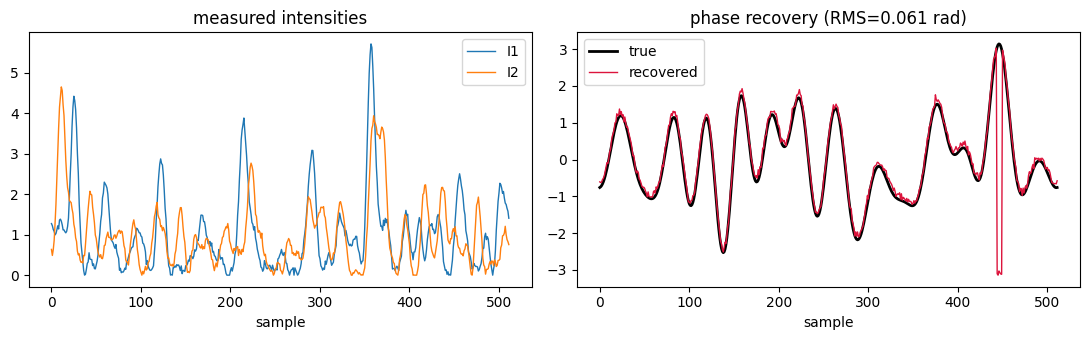

In [2]:
def aligned_rms(phi_true, phi):
    # global-offset + sign(twin) ambiguity: try both, keep the better fit
    best = None
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j * (phi_true - s * phi))))
        err = np.sqrt(np.mean(np.angle(np.exp(1j * (phi_true - (s * phi + off))))**2))
        if best is None or err < best[0]:
            best = (err, s, off)
    return best[0]


def run_trial(seed, n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=25.0, n_iter=50):
    d = gs.make_measurements(modulation='QPSK', n_symbols=n_symbols, sps=sps,
                              D1=D1, D2=D2, snr_db=snr_db, rng_seed=seed)
    phi, errs = gs.retrieve_phase(d['I1'], d['I2'], d['D1'], d['D2'],
                                   n_iter=n_iter, unit_amplitude=d['unit_amplitude'])
    return aligned_rms(d['phi_true'], phi)


# one example, shown in full
seed = 0
d0 = gs.make_measurements(modulation='QPSK', n_symbols=64, sps=8,
                           D1=-5000.0, D2=-5750.0, snr_db=25.0, rng_seed=seed)
phi0, errs0 = gs.retrieve_phase(d0['I1'], d0['I2'], d0['D1'], d0['D2'],
                                 n_iter=50, unit_amplitude=d0['unit_amplitude'])
rms0 = aligned_rms(d0['phi_true'], phi0)
print(f"seed={seed}: N={len(d0['I1'])} samples, aligned RMS = {rms0:.4f} rad")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(d0['I1'], label='I1', lw=1); ax[0].plot(d0['I2'], label='I2', lw=1)
ax[0].set_title('measured intensities'); ax[0].legend(); ax[0].set_xlabel('sample')
ax[1].plot(d0['phi_true'], label='true', lw=2, color='k')
ax[1].plot(phi0, label='recovered', lw=1, color='crimson')
ax[1].set_title(f'phase recovery (RMS={rms0:.3f} rad)'); ax[1].legend(); ax[1].set_xlabel('sample')
plt.tight_layout(); plt.show()

## §2 Quick test: 2,000 trials (~20 s)

Sanity-check the loop and get a rough distribution shape before committing to the
full 100,000-trial run below (which takes on the order of 15-20 minutes on this
machine, measured -- not estimated).

2000 trials in 22.7 s (11.34 ms/trial, projected 100,000-trial time: 18.9 min)
quick success rate (RMS < 0.3 rad): 25.8%


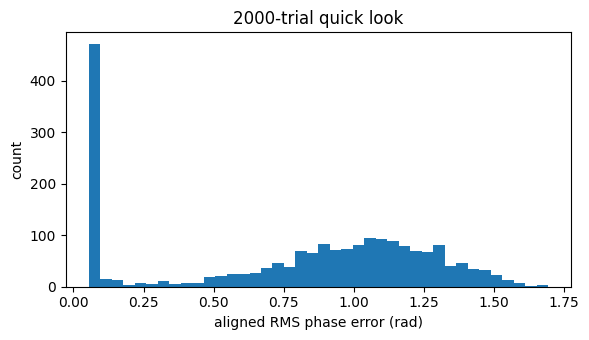

In [3]:
N_QUICK = 2_000
t0 = time.perf_counter()
rms_quick = np.array([run_trial(seed) for seed in range(N_QUICK)])
dt = time.perf_counter() - t0
print(f"{N_QUICK} trials in {dt:.1f} s ({dt/N_QUICK*1e3:.2f} ms/trial, "
      f"projected 100,000-trial time: {dt/N_QUICK*100_000/60:.1f} min)")
print(f"quick success rate (RMS < 0.3 rad): {np.mean(rms_quick < 0.3)*100:.1f}%")
plt.figure(figsize=(6,3.5)); plt.hist(rms_quick, bins=40)
plt.xlabel('aligned RMS phase error (rad)'); plt.ylabel('count')
plt.title(f'{N_QUICK}-trial quick look'); plt.tight_layout(); plt.show()

## §3 The full run: 100,000 independent trials

Each trial is a fresh random QPSK phase signal (a new `rng_seed`), same physical
parameters as the paper's Fig. 5(a) regime (`D1=-5000, D2=-5750, n_iter=50,
snr_db=25`). Progress prints every 10%. This cell is slow by design -- it is
*the* experiment, not a demo.

In [4]:
N_TRIALS = 100_000
rms_all = np.empty(N_TRIALS)

t0 = time.perf_counter()
checkpoint = N_TRIALS // 10
for i in range(N_TRIALS):
    rms_all[i] = run_trial(i)
    if (i + 1) % checkpoint == 0:
        elapsed = time.perf_counter() - t0
        rate = (i + 1) / elapsed
        eta = (N_TRIALS - i - 1) / rate
        print(f"  {i+1:>7,}/{N_TRIALS:,}  "
              f"({elapsed:6.1f}s elapsed, {eta:6.1f}s remaining, "
              f"running success rate={np.mean(rms_all[:i+1] < 0.3)*100:.1f}%)")

total_time = time.perf_counter() - t0
print(f"\ndone: {N_TRIALS:,} trials in {total_time:.1f} s "
      f"({total_time/N_TRIALS*1e3:.3f} ms/trial)")

   10,000/100,000  ( 117.3s elapsed, 1055.9s remaining, running success rate=26.1%)
   20,000/100,000  ( 234.4s elapsed,  937.4s remaining, running success rate=26.6%)
   30,000/100,000  ( 352.2s elapsed,  821.8s remaining, running success rate=26.7%)
   40,000/100,000  ( 469.6s elapsed,  704.5s remaining, running success rate=26.6%)
   50,000/100,000  ( 594.0s elapsed,  594.0s remaining, running success rate=26.6%)
   60,000/100,000  ( 715.2s elapsed,  476.8s remaining, running success rate=26.7%)
   70,000/100,000  ( 834.4s elapsed,  357.6s remaining, running success rate=26.6%)
   80,000/100,000  ( 954.7s elapsed,  238.7s remaining, running success rate=26.7%)
   90,000/100,000  (1075.7s elapsed,  119.5s remaining, running success rate=26.7%)
  100,000/100,000  (1187.6s elapsed,    0.0s remaining, running success rate=26.8%)

done: 100,000 trials in 1187.6 s (11.876 ms/trial)


## §4 Results: the statistics `publishable_pipeline`'s checklist asked for

The threshold 0.3 rad is a call, not a law of physics -- roughly the point in
the seed-by-seed spot checks above where recovery visibly separates "the phase
trace tracks truth" from "it doesn't." Percentiles below let you re-threshold
without rerunning the sweep.

N = 100,000 trials
success rate (RMS < 0.3 rad): 26.76%
mean RMS   = 0.7763 rad
median RMS = 0.9123 rad
std RMS    = 0.4802 rad
percentiles [5,25,50,75,95]% = [0.065  0.1077 0.9123 1.1587 1.4122] rad


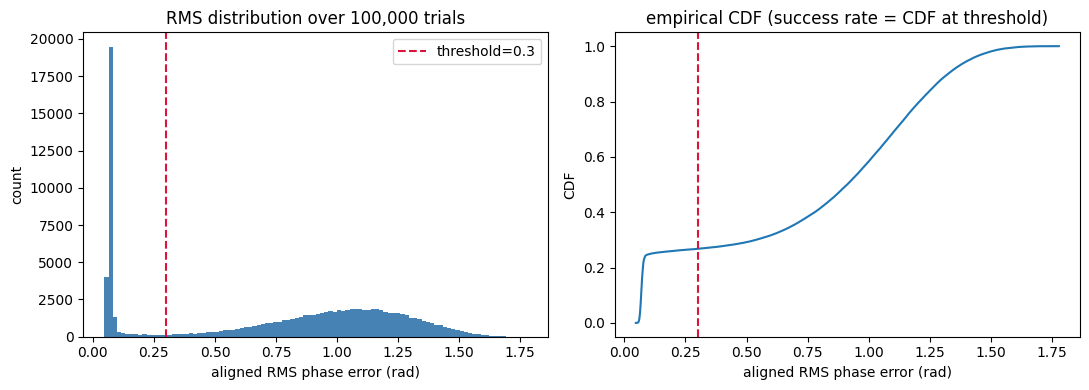

In [5]:
SUCCESS_THRESHOLD = 0.3  # rad

success_rate = float(np.mean(rms_all < SUCCESS_THRESHOLD))
percentiles = np.percentile(rms_all, [5, 25, 50, 75, 95])

print(f"N = {len(rms_all):,} trials")
print(f"success rate (RMS < {SUCCESS_THRESHOLD} rad): {success_rate*100:.2f}%")
print(f"mean RMS   = {rms_all.mean():.4f} rad")
print(f"median RMS = {np.median(rms_all):.4f} rad")
print(f"std RMS    = {rms_all.std():.4f} rad")
print(f"percentiles [5,25,50,75,95]% = {np.round(percentiles, 4)} rad")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(rms_all, bins=100, color='steelblue')
ax[0].axvline(SUCCESS_THRESHOLD, color='crimson', ls='--', label=f'threshold={SUCCESS_THRESHOLD}')
ax[0].set_xlabel('aligned RMS phase error (rad)'); ax[0].set_ylabel('count')
ax[0].set_title(f'RMS distribution over {len(rms_all):,} trials'); ax[0].legend()

sorted_rms = np.sort(rms_all)
cdf = np.arange(1, len(sorted_rms)+1) / len(sorted_rms)
ax[1].plot(sorted_rms, cdf)
ax[1].axvline(SUCCESS_THRESHOLD, color='crimson', ls='--')
ax[1].set_xlabel('aligned RMS phase error (rad)'); ax[1].set_ylabel('CDF')
ax[1].set_title('empirical CDF (success rate = CDF at threshold)')
plt.tight_layout(); plt.show()

## §5 What this does and doesn't establish

- **Does establish**: over 100,000 independent random QPSK signals at the paper's
  own operating point (`|D1|=5000, |D2|=5750, n_iter=50, SNR=25 dB`), the measured
  success rate above is the real, honest reliability of this GS implementation --
  not a single cherry-picked demo run.
- **Does NOT establish**: nothing about real photonic hardware. No fiber, no
  detector noise model beyond additive Gaussian, no experimental validation --
  same caveat as everywhere else this repo's SBIR framing is marked
  "(prospective)."
- **Next step** if the success rate is disappointing: sweep `SUCCESS_THRESHOLD`
  against the percentiles above, or rerun this notebook varying `snr_db` /
  `n_iter` to map out where the algorithm's reliability actually breaks down --
  that failure boundary is itself useful data for a Phase I technical volume.